# WEEK 1 of the Capstone Project 20.11.2025

## OVERALL AIM
You’ll be working with eight synthetic black-box functions. These are unknown mathematical functions that accept inputs and return a single output. Your goal is to find the inputs that give the highest possible output for each function.

## WEEK 1 AIM
1. Download the initial data
2. Visualise / better understand the data

In a different python notebook:
3. Analyse each model and suggest the most appropriate first point

### STEP 0 - IMPORT RELEVANT PACKAGES

In [2]:
import numpy as np
import os
from pathlib import Path
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

### STEP 1 - DOWNLOAD THE INITIAL DATA

In [3]:
# Set the base directory path
base_dir = Path('/Users/jackdunning/Documents/Github/Capstone-Project-Imperial-College-London/initial_data')

# Dictionary to store all loaded data
initial_data = {}

# Load data for each function
for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    function_dir = base_dir / function_name
    
    # Load inputs and outputs
    inputs_path = function_dir / 'initial_inputs.npy'
    outputs_path = function_dir / 'initial_outputs.npy'
    
    if inputs_path.exists() and outputs_path.exists():
        # Load data using np.load()
        inputs = np.load(inputs_path)
        outputs = np.load(outputs_path)
        
        initial_data[function_name] = {
            'inputs': inputs,
            'outputs': outputs
        }
    else:
        print(f"Warning: Files not found for {function_name}")


### STEP 3 - DECIDING WEEK 1 POINTS

### Function-1
Aim = plot a simple X,Y scatter plot to show the inputs.

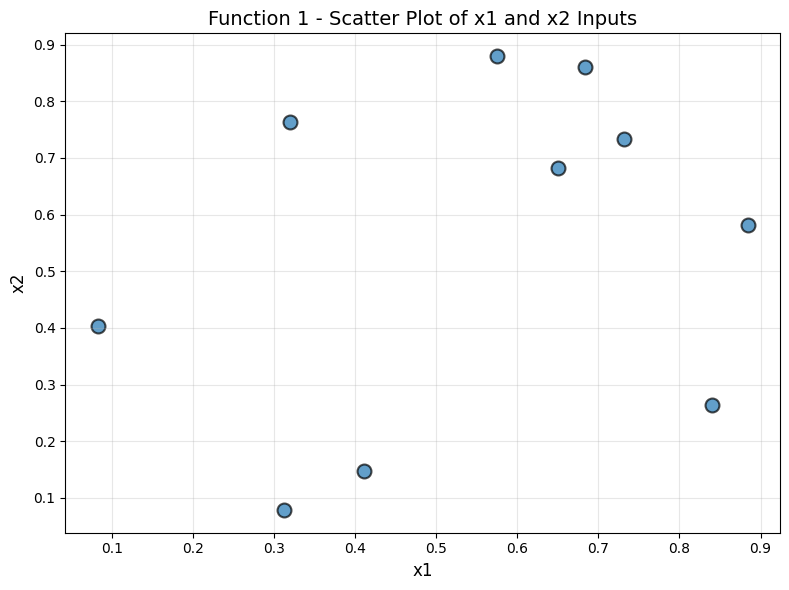

In [6]:
# Function 1 - Scatter plot of x1 and x2 inputs
function_name = 'function_1'
data = initial_data[function_name]
inputs = data['inputs']

# Extract x1 (first column) and x2 (second column)
x1 = inputs[:, 0]
x2 = inputs[:, 1]

# Create scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(x1, x2, s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.title('Function 1 - Scatter Plot of x1 and x2 Inputs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

CONCLUSION

The inputs are quite sparsely distributed, I am just going to choose a point X1=0.5, Y1=0.5 which is in the middle of the space.

### FUNCTION 2

Aim = plot a simple X,Y scatter plot to show the inputs.

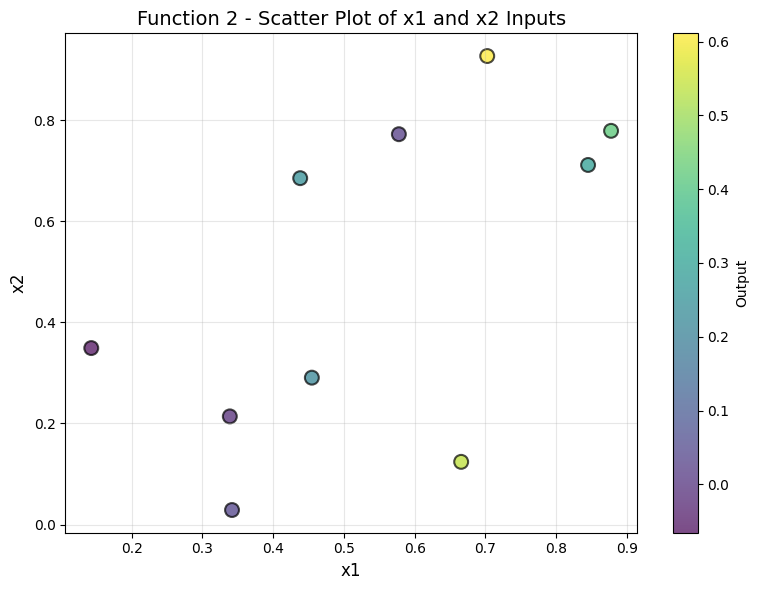

In [8]:
# Function 2 - Scatter plot of x1 and x2 inputs
function_name = 'function_2'
data = initial_data[function_name]
inputs = data['inputs']
outputs = data['outputs']

# Extract x1 (first column) and x2 (second column)
x1 = inputs[:, 0]
x2 = inputs[:, 1]

# Create scatter plot with color-coded outputs
plt.figure(figsize=(8, 6))
scatter = plt.scatter(x1, x2, c=outputs, cmap='viridis', s=100, alpha=0.7, edgecolors='black', linewidth=1.5)
plt.xlabel('x1', fontsize=12)
plt.ylabel('x2', fontsize=12)
plt.title('Function 2 - Scatter Plot of x1 and x2 Inputs', fontsize=14)
plt.grid(True, alpha=0.3)
plt.colorbar(scatter, label='Output')
plt.tight_layout()
plt.show()

CONCLUSION

Again here I'm going to pick a value in the middle of the space, where there is an unexplored region. But there seems to be a correlation of high outputs around X1 = 0.65. So I'm going to choose that, and then the X2 will sit in the middle of the other 2. 

x1 = 0.65
x2 = 0.5

### Function 3

For function 3 - the first 3D inputs. Here I am going to write a function that generates 5000 random points, then calculates the distance relative to the other inputs, and choses the value furthest away. So it picks a value in an unexplored space. 

Idea being, I want to explore unexplored space. 

In [12]:
# Function 3 - Find a point far from existing points using maximin sampling
function_name = 'function_3'
data = initial_data[function_name]
X = data['inputs']  # existing inputs (15×3)

# Set random seed for reproducibility
rng = np.random.default_rng(42)

# Generate 5000 candidate points
candidates = rng.uniform(0, 1, size=(5000, 3))

best_point = None
best_dist = -np.inf

for c in candidates:
    # Calculate distance to all existing points
    d = np.linalg.norm(X - c, axis=1)  # distance to all existing points
    min_d = d.min()                    # how close is the nearest known point?
    
    if min_d > best_dist:
        best_dist = min_d
        best_point = c

print(f"Best point (farthest from existing points): {best_point}")
print(f"Minimum distance to nearest existing point: {best_dist:.4f}")

Best point (farthest from existing points): [0.46675293 0.99044218 0.99626506]
Minimum distance to nearest existing point: 0.6243


CONCLUSION:
Best point (farthest from existing points): [0.46675293 0.99044218 0.99626506]


### FUNCTION 4 TO 8

I am running a little bit out of time / the larger dimensions are harder. So here I'm just going to write a similar function that finds a point in a relatively unexplored input area, and then submit that. 

In [ ]:
# Function to find a point far from existing points using maximin sampling
# Works for any dimension
def find_far_point(function_name, n_candidates=5000, random_seed=None):
    """
    Find a point that maximizes the minimum distance to existing points.
    
    Parameters:
    - function_name: str, name of the function (e.g., 'function_4')
    - n_candidates: int, number of candidate points to sample
    - random_seed: int, random seed for reproducibility
    
    Returns:
    - best_point: numpy array, the point farthest from existing points
    - best_dist: float, minimum distance to nearest existing point
    """
    data = initial_data[function_name]
    X = data['inputs']  # existing inputs
    
    n_dims = X.shape[1]  # get dimension from input shape
    
    # Set random seed
    rng = np.random.default_rng(random_seed)
    
    # Generate candidate points
    candidates = rng.uniform(0, 1, size=(n_candidates, n_dims))
    
    best_point = None
    best_dist = -np.inf
    
    for c in candidates:
        # Calculate distance to all existing points
        d = np.linalg.norm(X - c, axis=1)  # distance to all existing points
        min_d = d.min()                    # how close is the nearest known point?
        
        if min_d > best_dist:
            best_dist = min_d
            best_point = c
    
    return best_point, best_dist

# Apply to functions 4-8
for function_num in range(4, 9):
    function_name = f'function_{function_num}'
    data = initial_data[function_name]
    inputs = data['inputs']
    
    best_point, best_dist = find_far_point(function_name, n_candidates=5000, random_seed=42)
    
    print(f"\n{function_name}:")
    print(f"  Inputs shape: {inputs.shape}")
    print(f"  Best point (farthest from existing points): {np.round(best_point, 4)}")
    print(f"  Minimum distance to nearest existing point: {best_dist:.4f}")

###PRINTING ALL OUTPUTS IN FORMAT FOR UPLOAD

In [14]:
# Define next points for functions 1-2 (manually chosen)
next_points = {
    'function_1': np.array([0.5, 0.5]),
    'function_2': np.array([0.65, 0.5])
}

# Find next points for functions 3-8 using maximin sampling
for function_num in range(3, 9):
    function_name = f'function_{function_num}'
    best_point, _ = find_far_point(function_name, n_candidates=5000, random_seed=42)
    next_points[function_name] = best_point

# Print all next points in the required format
print("=" * 60)
for function_num in range(1, 9):
    function_name = f'function_{function_num}'
    point = next_points[function_name]
    
    # Format as x1-x2-x3-x4... etc.
    formatted_point = '-'.join([f'{x:.6f}' for x in point])
    
    print(f"Next point for {function_name}:")
    print(formatted_point)
    print()
print("=" * 60)

Next point for function_1:
0.500000-0.500000

Next point for function_2:
0.650000-0.500000

Next point for function_3:
0.466753-0.990442-0.996265

Next point for function_4:
0.013827-0.388082-0.736064-0.971728

Next point for function_5:
0.937239-0.959791-0.960767-0.818897

Next point for function_6:
0.819854-0.036171-0.929157-0.042194-0.938540

Next point for function_7:
0.057395-0.931572-0.975502-0.005642-0.900680-0.173960

Next point for function_8:
0.824416-0.925687-0.201348-0.929573-0.017861-0.924962-0.951929-0.012052

